## Music Recommendation Algorithim - Exploratory Data Analysis 

Here in this notebook I will perform univariate, bivariate, and multivariate exploratory analysis on a dateset of songs from 1950 to 2019. The goal is to understand the relationships between our lyrical features before we move on to clustering. 


In [3]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats

In [4]:
#Loading dataset
df = pd.read_csv('data/music_rec/train.csv')

In [5]:
#Quick overview of the data
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Shape: (28362, 24)
Rows: 28362, Columns: 24


In [9]:
print('Columns for the Dataset:', list(df.columns))

Columns for the Dataset: ['Unnamed: 0', 'artist_name', 'track_name', 'release_date', 'genre', 'lyrics', 'len', 'dating', 'violence', 'world/life', 'night/time', 'shake the audience', 'family/gospel', 'romantic', 'communication', 'obscene', 'music', 'movement/places', 'light/visual perceptions', 'family/spiritual', 'sadness', 'feelings', 'topic', 'age']


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28362 entries, 0 to 28361
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                28362 non-null  int64  
 1   artist_name               28362 non-null  object 
 2   track_name                28362 non-null  object 
 3   release_date              28362 non-null  int64  
 4   genre                     28362 non-null  object 
 5   lyrics                    28362 non-null  object 
 6   len                       28362 non-null  int64  
 7   dating                    28362 non-null  float64
 8   violence                  28362 non-null  float64
 9   world/life                28362 non-null  float64
 10  night/time                28362 non-null  float64
 11  shake the audience        28362 non-null  float64
 12  family/gospel             28362 non-null  float64
 13  romantic                  28362 non-null  float64
 14  commun

In [11]:
print('First 10 Rows')
df.head(10)

First 10 Rows


,Unnamed: 0,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,...,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,topic,age
0,0,mukesh,mohabbat bhi jhoothi,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,...,0.263751,0.000598,0.039288,0.000598,0.000598,0.000598,0.380299,0.117175,sadness,1.0
1,4,frankie laine,i believe,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,...,0.001284,0.001284,0.118034,0.001284,0.212681,0.051124,0.001284,0.001284,world/life,1.0
2,6,johnnie ray,cry,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,...,0.250668,0.002770,0.323794,0.002770,0.002770,0.002770,0.002770,0.225422,music,1.0
3,10,pérez prado,patricia,1950,pop,kiss lips want stroll charm mambo chacha merin...,54,0.048249,0.001548,0.001548,...,0.001548,0.001548,0.001548,0.129250,0.001548,0.001548,0.225889,0.001548,romantic,1.0
4,12,giorgos papadopoulos,apopse eida oneiro,1950,pop,till darling till matter know till dream live ...,48,0.001350,0.001350,0.417772,...,0.001350,0.001350,0.001350,0.001350,0.001350,0.029755,0.068800,0.001350,romantic,1.0
5,14,perry como,round and round (with mitchell ayres and his o...,1950,pop,convoy light dead ahead merchantmen trump dies...,98,0.001053,0.420685,0.001053,...,0.001053,0.001053,0.001053,0.001053,0.172173,0.001053,0.128292,0.001053,violence,1.0
6,15,freestyle,opm medley: when i met you,1950,pop,piece mindin world knowin life come bring give...,179,0.000483,0.000483,0.371817,...,0.384703,0.000483,0.000483,0.000483,0.044355,0.000483,0.000483,0.123150,world/life,1.0
7,17,johnny mathis,it's not for me to say,1950,pop,care moment hold fast press lips dream heaven ...,21,0.002506,0.002506,0.336056,...,0.002506,0.002506,0.002506,0.002506,0.386887,0.002506,0.062602,0.002506,world/life,1.0
8,20,stélios kazantzídis,klapse me mana klapse me,1950,pop,lonely night surround power read mind hour nig...,30,0.083537,0.002024,0.002024,...,0.167783,0.002024,0.002024,0.002024,0.002024,0.002024,0.002024,0.031600,romantic,1.0
9,23,stélios kazantzídis,finito la mouzika,1950,pop,tear heart seat stay awhile tear heart game st...,61,0.001120,0.102548,0.001120,...,0.091572,0.001120,0.001120,0.105752,0.001120,0.001120,0.630507,0.001120,sadness,1.0


In [ ]:
print('Last 10 Rows')
df.tail(10)

Last 10 Rows


,Unnamed: 0,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,...,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,topic,age
28352,82439,rakim,when i b on tha mic,2019,hip hop,internationally know hardcore real niggas inte...,58,0.001754,0.001754,0.001754,...,0.001754,0.722233,0.001754,0.001754,0.055028,0.001754,0.001754,0.095745,obscene,0.014286
28353,82440,ja rule,kill 'em all,2019,hip hop,spit shit damn nigga ridiculous nigga lose inc...,75,0.068214,0.242461,0.001074,...,0.001074,0.411752,0.001074,0.001074,0.001074,0.001074,0.001074,0.043749,obscene,0.014286
28354,82442,nipsey hussle,hussle in the house,2019,hip hop,look comin straight slauson crazy motherfucker...,88,0.001096,0.001096,0.001096,...,0.001096,0.733959,0.001096,0.001096,0.122627,0.001096,0.001096,0.001096,obscene,0.014286
28355,82445,nappy roots,country boyz,2019,hip hop,hook country boys country walk country talk br...,109,0.000810,0.000810,0.000810,...,0.000810,0.394272,0.000810,0.515379,0.000810,0.000810,0.000810,0.000810,obscene,0.014286
28356,82446,the roots,the seed (2.0),2019,hip hop,knock months finna know want neosoul hiphop wa...,61,0.001224,0.001224,0.105172,...,0.001224,0.325359,0.001224,0.001224,0.165883,0.001224,0.001224,0.001224,obscene,0.014286
28357,82447,mack 10,10 million ways,2019,hip hop,cause fuck leave scar tick tock clock come kno...,78,0.001350,0.001350,0.001350,...,0.001350,0.391651,0.001350,0.435089,0.001350,0.001350,0.065664,0.001350,obscene,0.014286
28358,82448,m.o.p.,ante up (robbin hoodz theory),2019,hip hop,minks things chain ring braclets yap fame come...,67,0.001284,0.001284,0.035338,...,0.203889,0.318910,0.058152,0.134955,0.001284,0.001284,0.001284,0.001284,obscene,0.014286
28359,82449,nine,whutcha want?,2019,hip hop,get ban get ban stick crack relax plan attack ...,77,0.001504,0.154302,0.168988,...,0.001504,0.356685,0.001504,0.068684,0.001504,0.001504,0.001504,0.001504,obscene,0.014286
28360,82450,will smith,switch,2019,hip hop,check check yeah yeah hear thing call switch g...,67,0.001196,0.001196,0.001196,...,0.001196,0.492434,0.103614,0.001196,0.202659,0.001196,0.001196,0.001196,obscene,0.014286
28361,82451,jeezy,r.i.p.,2019,hip hop,remix killer alive remix thriller trap bitch s...,83,0.001012,0.075202,0.001012,...,0.001012,0.754444,0.046284,0.001012,0.001012,0.001012,0.001012,0.033995,obscene,0.014286


In [ ]:
#Checking for any missing values
print('Displaying any missing values')
df.isnull().sum()

Displaying any missing values


Unnamed: 0                  0
artist_name                 0
track_name                  0
release_date                0
genre                       0
lyrics                      0
len                         0
dating                      0
violence                    0
world/life                  0
night/time                  0
shake the audience          0
family/gospel               0
romantic                    0
communication               0
obscene                     0
music                       0
movement/places             0
light/visual perceptions    0
family/spiritual            0
sadness                     0
feelings                    0
topic                       0
age                         0
dtype: int64

In [14]:
#Checking for duplicated rows
print('Checking for duplicates:', df.duplicated().sum())

Checking for duplicates: 0


In [17]:
print('These are the data types for the dataset columns')
df.dtypes

These are the data types for the dataset columns


Unnamed: 0                    int64
artist_name                  object
track_name                   object
release_date                  int64
genre                        object
lyrics                       object
len                           int64
dating                      float64
violence                    float64
world/life                  float64
night/time                  float64
shake the audience          float64
family/gospel               float64
romantic                    float64
communication               float64
obscene                     float64
music                       float64
movement/places             float64
light/visual perceptions    float64
family/spiritual            float64
sadness                     float64
feelings                    float64
topic                        object
age                         float64
dtype: object

In [45]:
df.describe()

,Unnamed: 0,release_date,len,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,age
count,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000,28362.000000
mean,42948.166878,1990.239652,73.030534,0.021110,0.118371,0.120984,0.057356,0.017418,0.017045,0.048676,0.076651,0.097185,0.060067,0.047417,0.049008,0.024155,0.129402,0.030995,0.425148
std,24747.811462,18.486997,41.831605,0.052366,0.178658,0.172216,0.111892,0.040658,0.041968,0.106071,0.109497,0.181314,0.123346,0.091559,0.089553,0.051032,0.181149,0.071656,0.264100
min,0.000000,1950.000000,1.000000,0.000291,0.000284,0.000291,0.000289,0.000284,0.000289,0.000284,0.000291,0.000289,0.000289,0.000284,0.000284,0.000284,0.000284,0.000289,0.014286
25%,20393.500000,1975.000000,42.000000,0.000923,0.001120,0.001170,0.001032,0.000993,0.000923,0.000975,0.001144,0.001053,0.000975,0.000993,0.000993,0.000957,0.001144,0.000993,0.185714
50%,45407.000000,1991.000000,63.000000,0.001462,0.002506,0.006579,0.001949,0.001595,0.001504,0.001754,0.002632,0.001815,0.001815,0.001645,0.001815,0.001645,0.005263,0.001754,0.414286
75%,64089.500000,2007.000000,93.000000,0.004049,0.192538,0.197854,0.065778,0.009989,0.004785,0.042304,0.132111,0.088799,0.055109,0.054373,0.064302,0.025515,0.235115,0.032617,0.642857
max,82451.000000,2019.000000,199.000000,0.647706,0.981781,0.962105,0.973684,0.497463,0.545303,0.940789,0.645829,0.992298,0.956938,0.638021,0.667782,0.618073,0.981424,0.958810,1.000000


### Univariate Analysis
I will start by looking at each variable individually to understand distributions and spot anything unusual. 

Genre Distribution:
genre
pop        7038
country    5444
blues      4603
rock       4032
jazz       3844
reggae     2497
hip hop     904
Name: count, dtype: int64


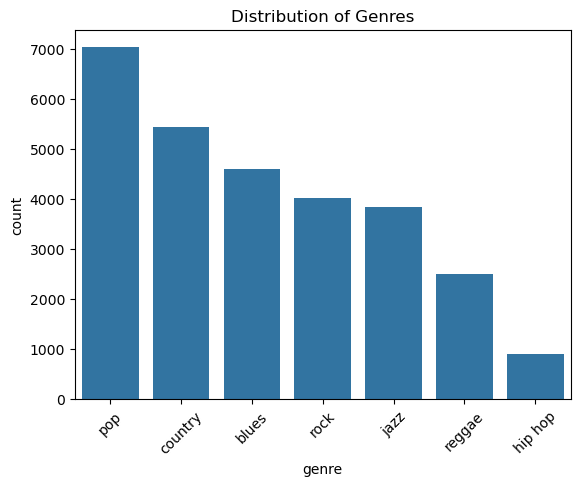

In [19]:
#What is the distribution of genres in our dataset?
print('Genre Distribution:')
print(df['genre'].value_counts())

sns.countplot(x ='genre', data = df, order = df['genre'].value_counts().index)
plt.title('Distribution of Genres')
plt.xticks(rotation = 45)
plt.show()

What does the topic distribution look like?

Topic Distribution:
topic
sadness       6094
violence      5707
world/life    5419
obscene       4881
music         2303
night/time    1823
romantic      1523
feelings       612
Name: count, dtype: int64


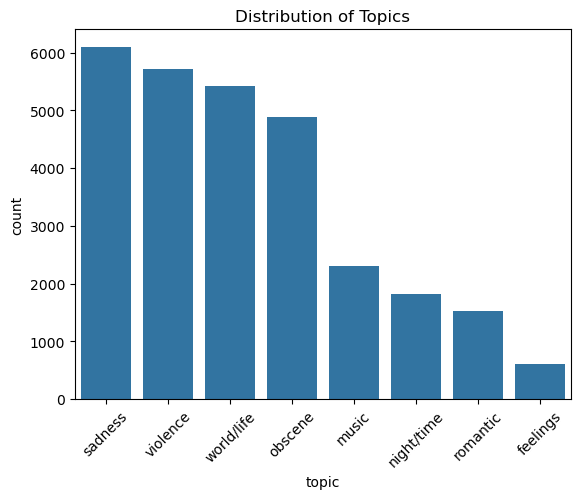

In [20]:
#Topic distribution

print("Topic Distribution:")
print(df['topic'].value_counts())

sns.countplot(x = 'topic', data = df, order = df['topic'].value_counts().index)
plt.title('Distribution of Topics')
plt.xticks(rotation = 45)
plt.show()

When were most of these songs released?

Release Date Statistics:
count    28362.000000
mean      1990.239652
std         18.486997
min       1950.000000
25%       1975.000000
50%       1991.000000
75%       2007.000000
max       2019.000000
Name: release_date, dtype: float64


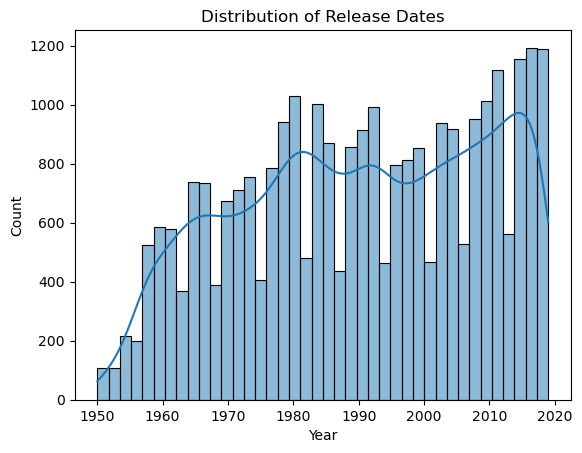

In [22]:
#Release date distribution
print('Release Date Statistics:')
print(df['release_date'].describe())

sns.histplot(df['release_date'], bins = 40, kde = True)
plt.title('Distribution of Release Dates')
plt.xlabel('Year')
plt.show()

How long are the lyrics in these songs?

Lyrics Length Statistics:
count    28362.000000
mean        73.030534
std         41.831605
min          1.000000
25%         42.000000
50%         63.000000
75%         93.000000
max        199.000000
Name: len, dtype: float64


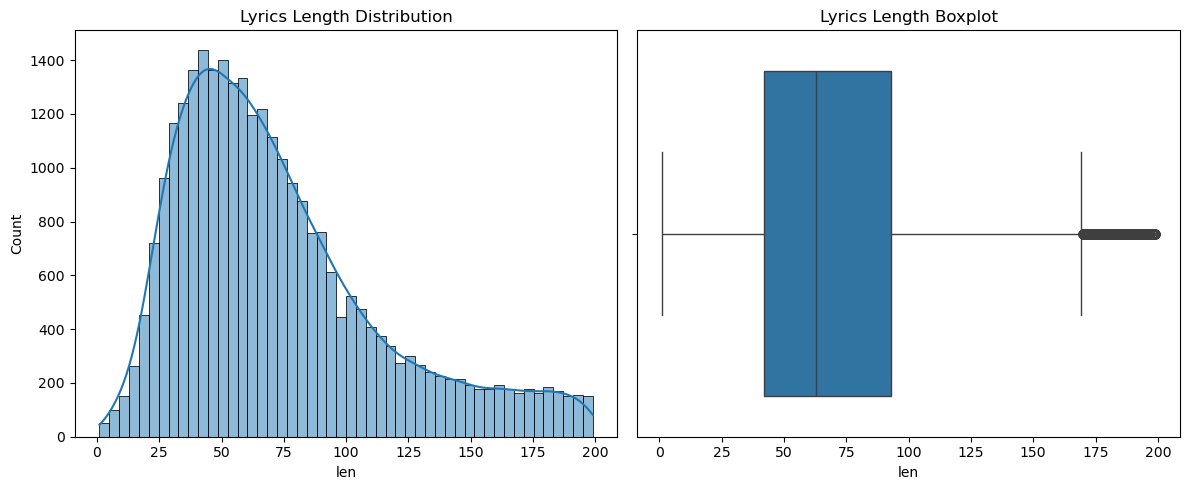

In [23]:
#Lyrics length distribution
print('Lyrics Length Statistics:')
print(df['len'].describe())

fig, axes = plt.subplots(1, 2, figsize = (12, 5))
sns.histplot(df['len'], bins = 50, kde = True, ax = axes[0])
axes[0].set_title('Lyrics Length Distribution')
sns.boxplot(x = df['len'], ax = axes[1])
axes[1].set_title('Lyrics Length Boxplot')
plt.tight_layout()
plt.show()

What do the topic score features look like? These are all scored 0 to 1.

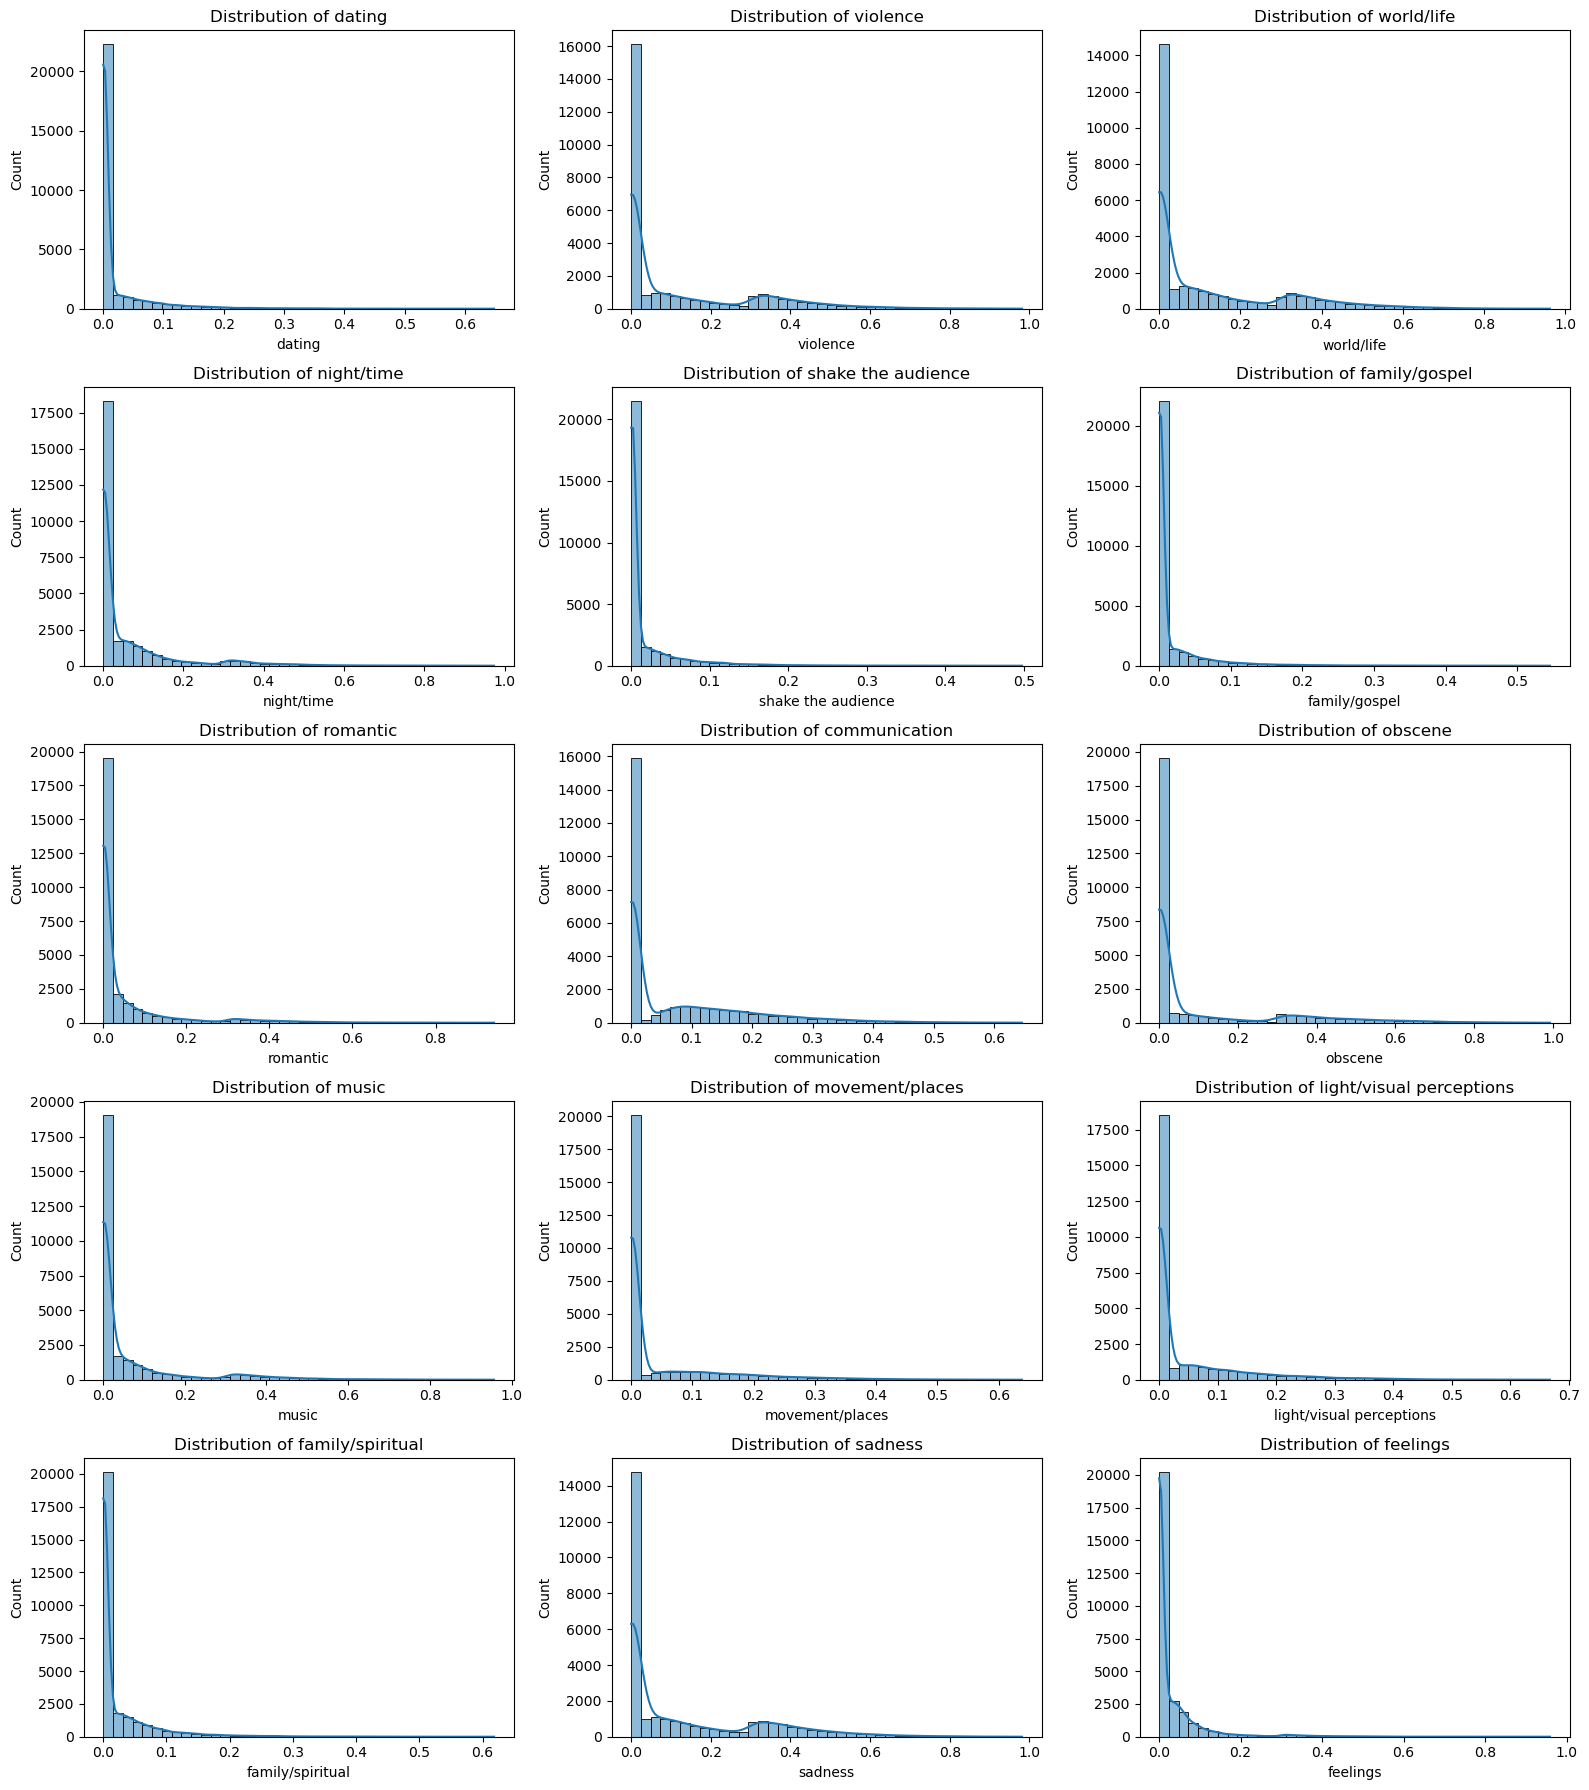

In [25]:
#Distribution of all topic score features

topic_features = ['dating', 'violence', 'world/life', 'night/time', 'shake the audience', 
                  'family/gospel', 'romantic', 'communication', 'obscene', 'music', 
                  'movement/places', 'light/visual perceptions', 'family/spiritual', 'sadness', 'feelings']

fig, axes = plt.subplots(5, 3, figsize = (16, 18))
axes = axes.flatten()

for i, col in enumerate(topic_features):
    sns.histplot(df[col], bins = 40, kde = True, ax = axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

Most of the topic scores are heavily right-skewed. The majority of songs score very low on any given topic with only a few scoring high. This makes sense because a song is usually only about one or two themes. 

What does the age feature look like? 

Age Statisctics:
count    28362.000000
mean         0.425148
std          0.264100
min          0.014286
25%          0.185714
50%          0.414286
75%          0.642857
max          1.000000
Name: age, dtype: float64


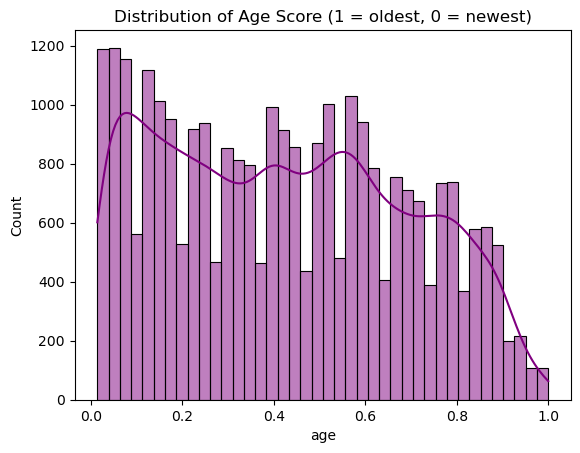

In [26]:
#Age Distribution
print('Age Statisctics:')
print(df['age'].describe())

sns.histplot(df['age'], bins = 40, kde = True, color = 'purple')
plt.title('Distribution of Age Score (1 = oldest, 0 = newest)')
plt.show()

## Bivariate Analysis 
Now I want to look at the relationship between pairs of variables.

How do topic scores differ across genres? 

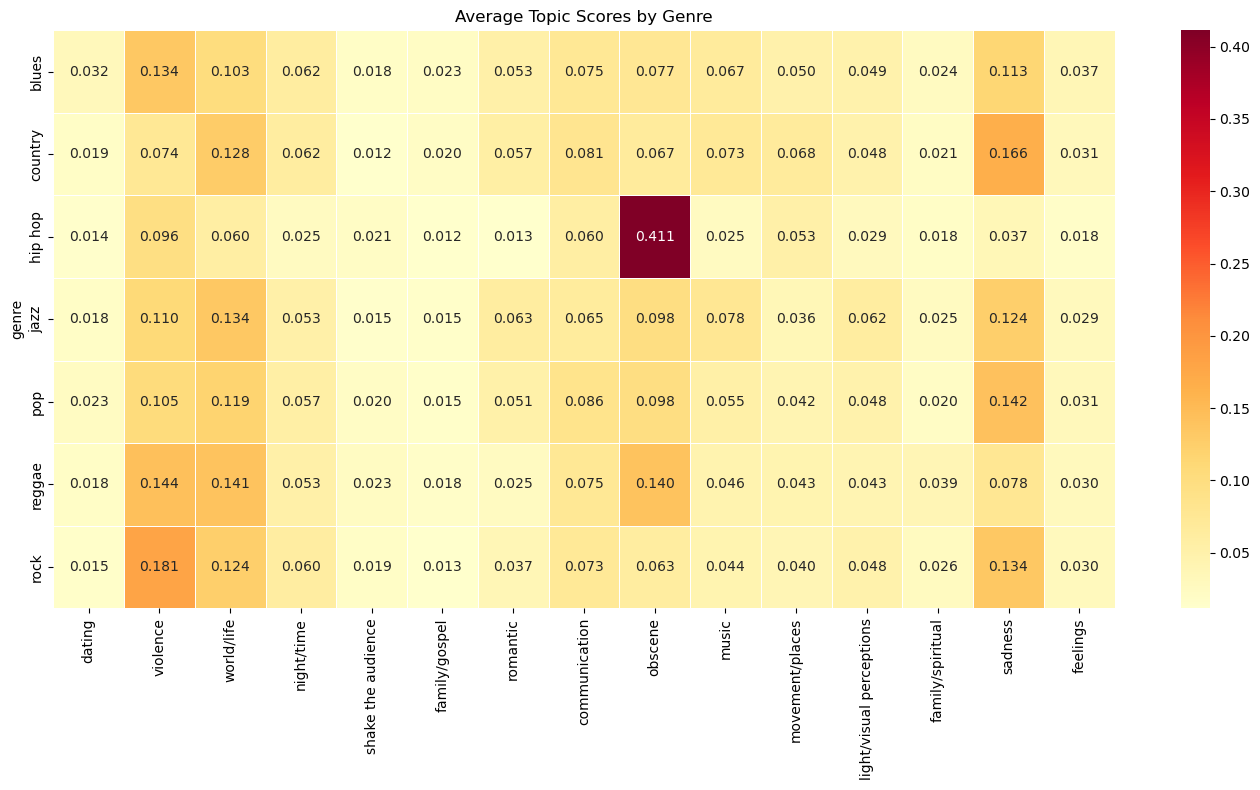

In [47]:
#Average topic scores by genre
genre_means = df.groupby('genre')[topic_features].mean()

plt.figure(figsize = (14, 8))
sns.heatmap(genre_means, annot = True, fmt = '.3f', cmap = 'YlOrRd', linewidths = 0.5)
plt.title('Average Topic Scores by Genre')
plt.tight_layout()
plt.show()

How does lyrics length vary by genre? 

Average lyrics length by genre
genre
reggae     98.685222
hip hop    98.292035
pop        78.904945
jazz       72.100676
rock       66.426339
blues      63.715186
country    62.898420
Name: len, dtype: float64


/var/folders/05/zl6tqd017kvgz3lqdhqp28vw0000gn/T/ipykernel_31154/3938107903.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = 'genre', y = 'len', palette = 'Set2')


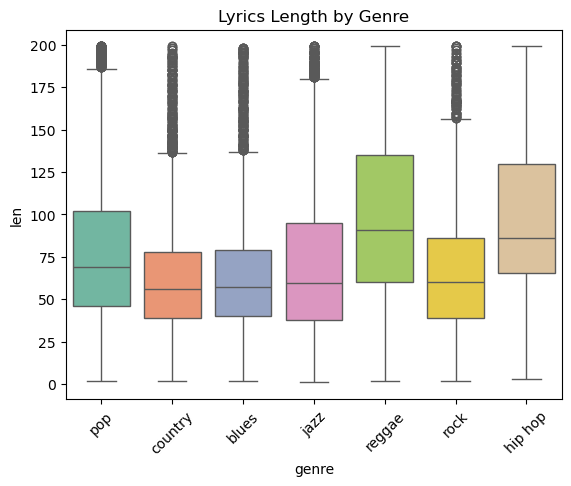

In [32]:
#Lyrics length by genre 
print('Average lyrics length by genre')
print(df.groupby('genre')['len'].mean().sort_values(ascending = False))

sns.boxplot(data = df, x = 'genre', y = 'len', palette = 'Set2')
plt.title('Lyrics Length by Genre')
plt.xticks(rotation = 45)
plt.show()

How does age score distribute across genres?

/var/folders/05/zl6tqd017kvgz3lqdhqp28vw0000gn/T/ipykernel_31154/1343571956.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = 'genre', y = 'age', palette = 'Set3')


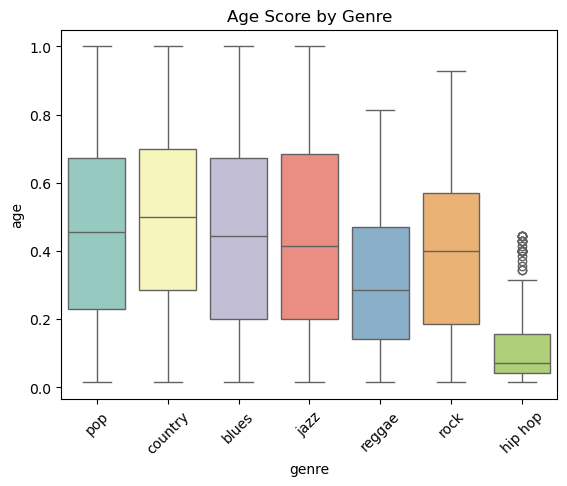

In [33]:
#Age by genre
sns.boxplot(data = df, x = 'genre', y = 'age', palette = 'Set3')
plt.title('Age Score by Genre')
plt.xticks(rotation = 45)
plt.show()

Is there a relationship between violence and obscene scores?

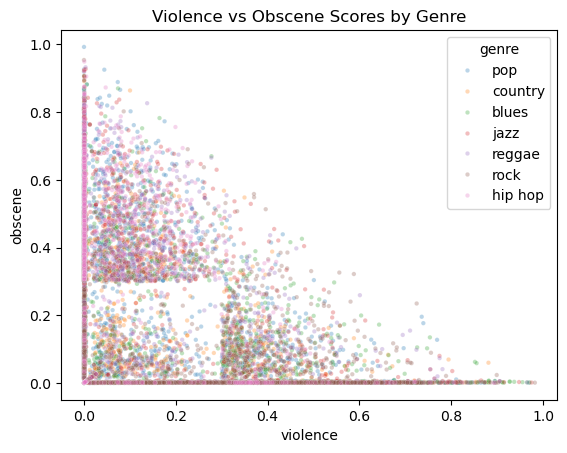

In [34]:
#Violence vs obscene 
sns.scatterplot(data = df, x = 'violence', y = 'obscene', hue = 'genre', alpha = 0.3, s = 10)
plt.title('Violence vs Obscene Scores by Genre')
plt.show()


WHat about romatic vs sadness?

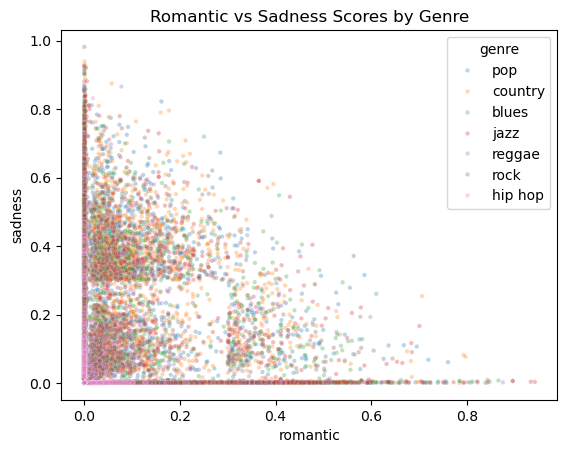

In [35]:
#Romantic vs sadness
sns.scatterplot(data = df, x = 'romantic', y = 'sadness', hue = 'genre', alpha = 0.3, s = 10)
plt.title('Romantic vs Sadness Scores by Genre')
plt.show()

How has average lyrics length changed over time? 

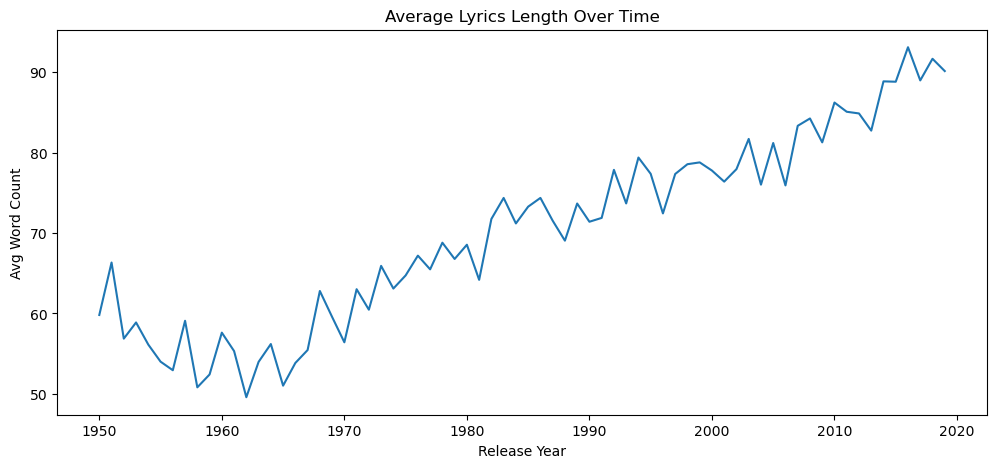

In [37]:
#Average lyrics length over time
avg_len_by_year = df.groupby('release_date')['len'].mean()

plt.figure(figsize = (12, 5))
plt.plot(avg_len_by_year.index, avg_len_by_year.values, linewidth = 1.5)
plt.title('Average Lyrics Length Over Time')
plt.xlabel('Release Year')
plt.ylabel('Avg Word Count')
plt.show()

Is there a statistically significant difference in lyrics length across genres? 

In [38]:
#Kruskal-Wallis test for lyrics length across genres 
groups = [group['len'].values for name, group in df.groupby('genre')]
stat, p_value = stats.kruskal(*groups)
print(f'Kruskal-Wallis H statistic: {stat:2f}')
print(f'P-value: {p_value:.6f}')

if p_value < 0.05:
    print('Statistically significant difference in lyrics length across genres (p < 0.05)')
else: 
    print('No significant difference found (p >= 0.05)')

Kruskal-Wallis H statistic: 1788.718025
P-value: 0.000000
Statistically significant difference in lyrics length across genres (p < 0.05)


## Multivariate Analysis
Now I want to look at how multiple features interact together.

What does the correlation heatmap look like for all numeric features?

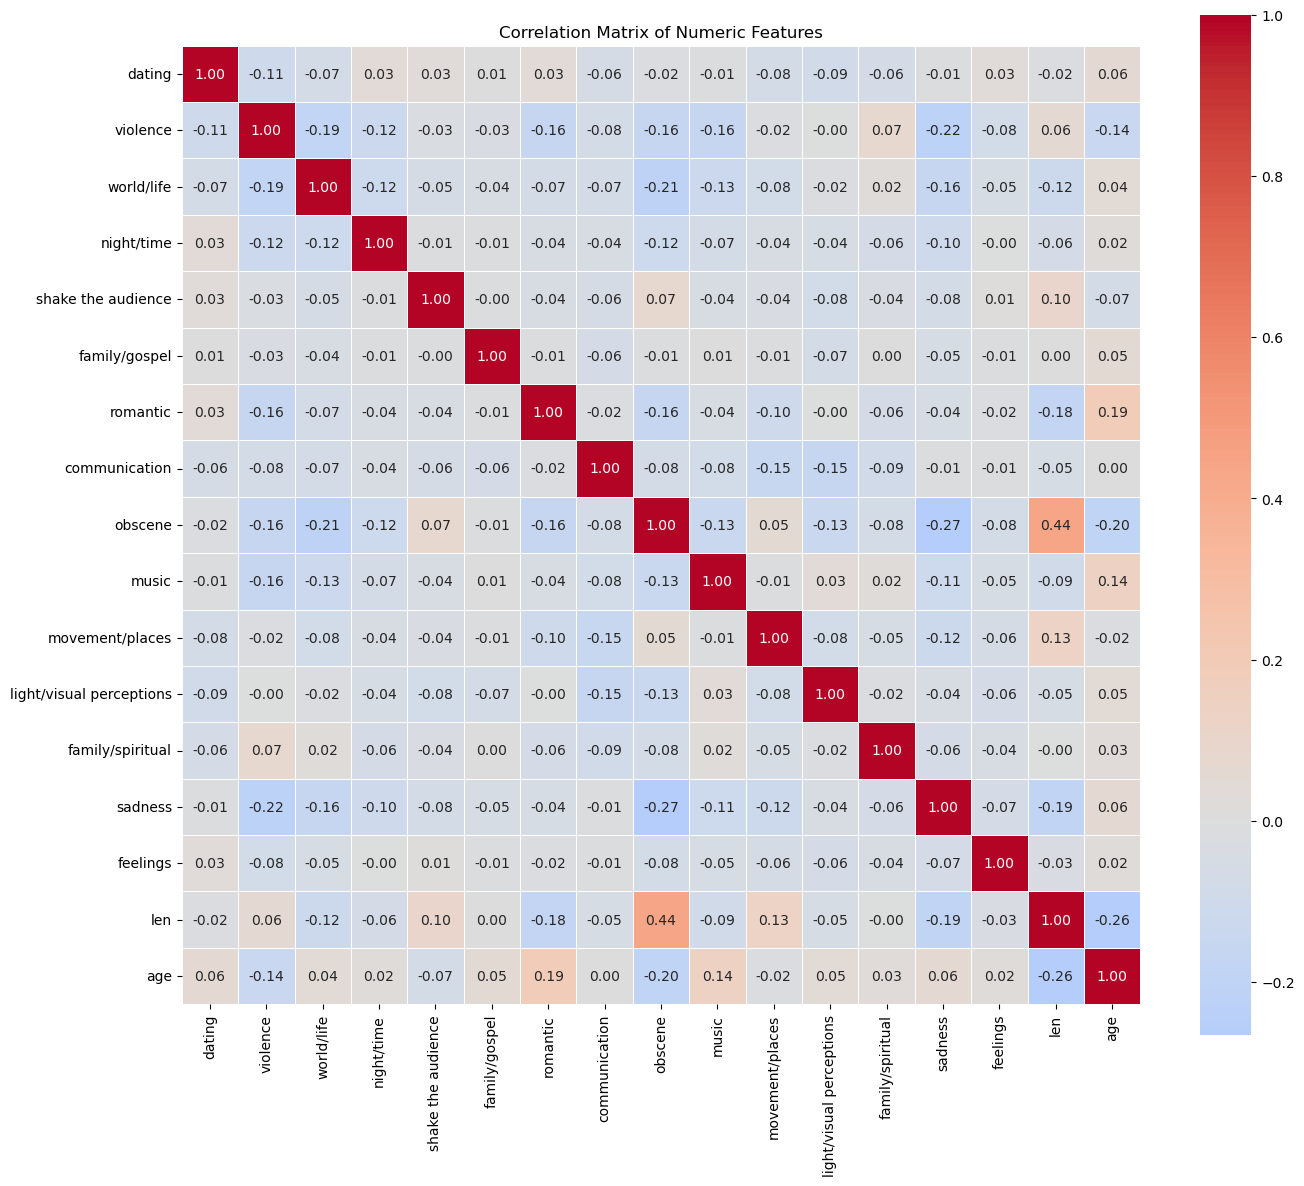

In [39]:
#Correlation matrix
numeric_cols = topic_features + ['len', 'age']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize = (14, 12))
sns.heatmap(corr_matrix, annot = True, fmt = '.2f', cmap = 'coolwarm', center = 0,
            linewidths = 0.5, square = True)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

Which feature pairs are highly correlated?

In [43]:
#Finding highly correlated pairs
print("Highly correlated feature pairs (|r| > 0.5)")
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.5:
            print(f" {corr_matrix.columns[i]} & {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.4f}")

Highly correlated feature pairs (|r| > 0.5)


In [46]:
#Lowering threshold since no pairs exceeded 0.5
print("Moderately correlated feature pairs (|r| > 0.3):\n")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.3:
            print(f"  {corr_matrix.columns[i]} & {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.4f}")

Moderately correlated feature pairs (|r| > 0.3):

  obscene & len: 0.4384


Do topic scores differ significantly across genres?

In [41]:
#Kruskal-Wallis test for each topic score across genres
print("Kruskal-Wallis Test: Do topic scores differ significantly across genres?\n")
for col in topic_features:
    groups = [group[col].values for name, group in df.groupby('genre')]
    stat, p_value = stats.kruskal(*groups)
    sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    print(f"  {col}: H={stat:.2f}, p={p_value:.6f} {sig}")

Kruskal-Wallis Test: Do topic scores differ significantly across genres?

  dating: H=465.35, p=0.000000 ***
  violence: H=868.88, p=0.000000 ***
  world/life: H=248.00, p=0.000000 ***
  night/time: H=331.91, p=0.000000 ***
  shake the audience: H=109.32, p=0.000000 ***
  family/gospel: H=479.73, p=0.000000 ***
  romantic: H=710.70, p=0.000000 ***
  communication: H=68.19, p=0.000000 ***
  obscene: H=1399.49, p=0.000000 ***
  music: H=572.03, p=0.000000 ***
  movement/places: H=520.35, p=0.000000 ***
  light/visual perceptions: H=339.79, p=0.000000 ***
  family/spiritual: H=321.03, p=0.000000 ***
  sadness: H=896.24, p=0.000000 ***
  feelings: H=181.15, p=0.000000 ***


What do the pairwise relationships look like between the top scoring features?

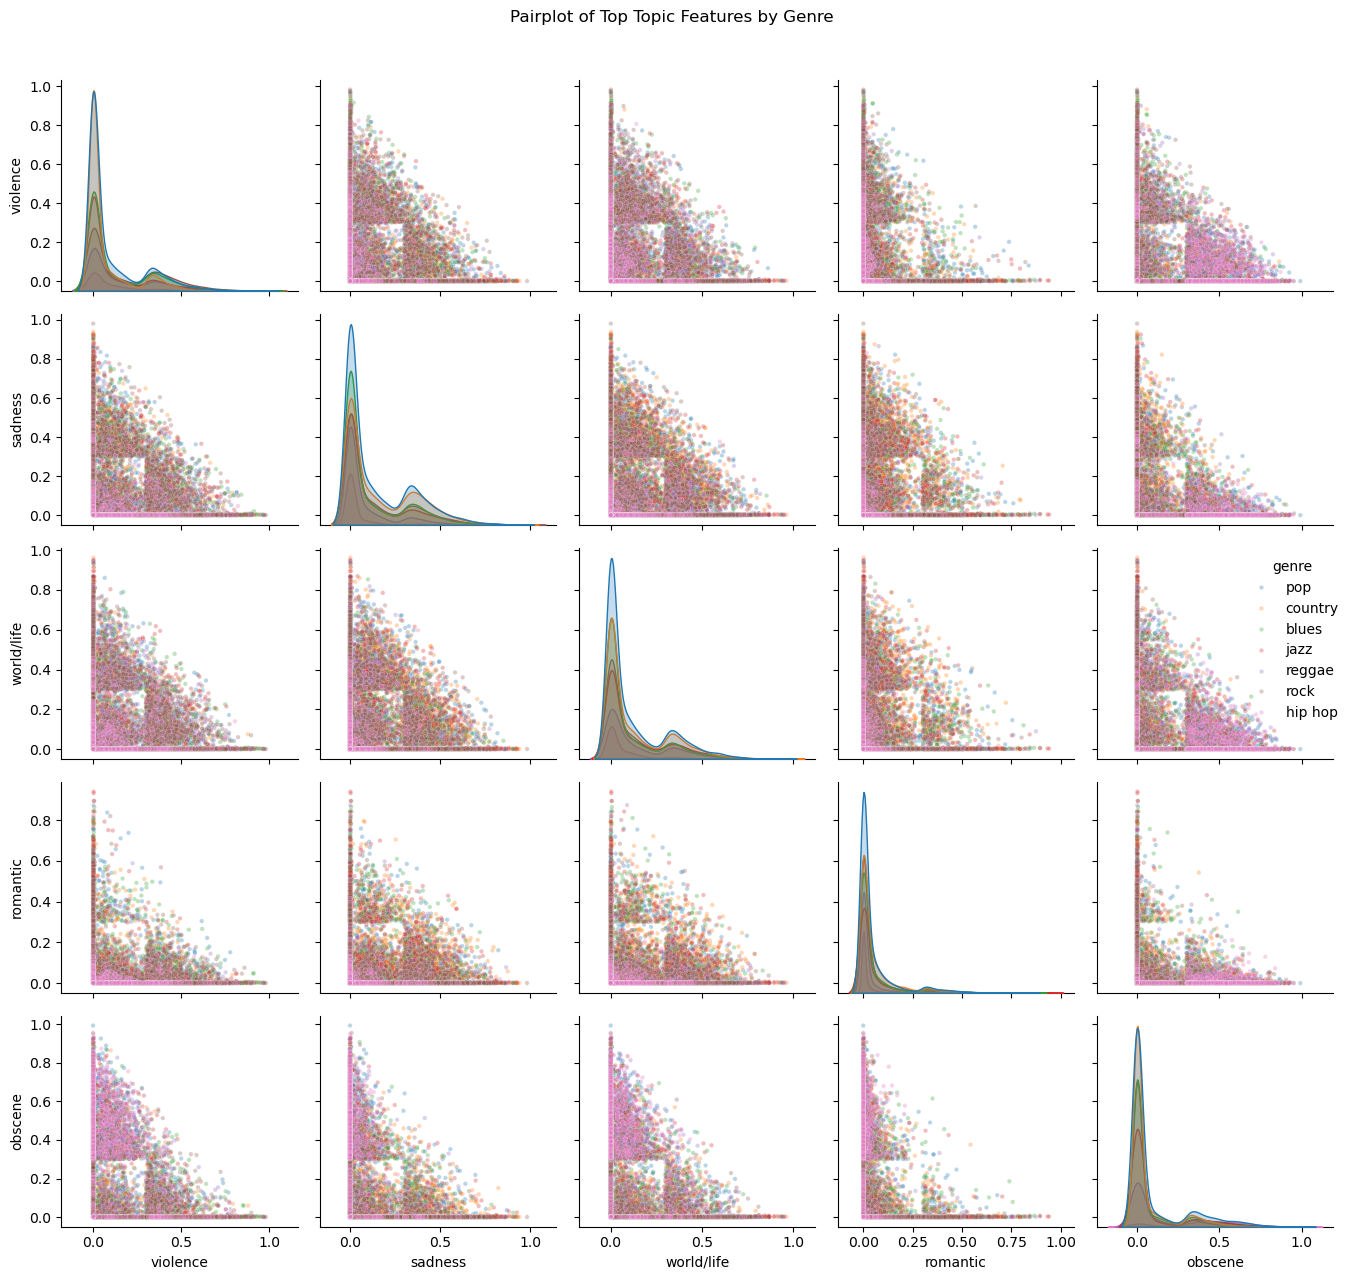

In [44]:
#Pairplot of top features
top_features = ['violence', 'sadness', 'world/life', 'romantic', 'obscene']
sns.pairplot(df[top_features + ['genre']], hue='genre', diag_kind='kde',
             plot_kws={'alpha': 0.3, 's': 10}, height=2.5)
plt.suptitle('Pairplot of Top Topic Features by Genre', y=1.02)
plt.tight_layout()
plt.show()

## EDA Summary 

- No null values or duplicates in the dataset so minimal cleaning needed
- Genre distribution is somewhat imbalanced with pop having the most songs (7,083) and hip hop the fewest (904)
- Topic scores are heavily right-skewed meaning most songs score low on any given topic with only a few scoring high
- No highly correlated pairs above 0.5 but obscene and len showed moderate correlation. Most features are fairly independent which is good for clustering.
- Hip hop stands out as having by far the highest obscene scores and the newest songs in the dataset
- Lyrics have gotten longer over time going from average 50 words in the 1950s to average 90+ words by 2015. 
- Kruskal-Wallis tests confirmed that ALL topic scores differ significantly across genres (p < 0.001 for every feature)
- These finding will guide our data cleaning and feature selection before we move into clustering. 
